In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import EpiClockNBL.util as nbl_util
nbl_consts = nbl_util.consts

import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)


def iad(clinical_tbl):
    '''
    iad = in analysis dataset
    '''
    return clinical_tbl.loc[clinical_tbl['in_analysis_dataset']].copy()

In [2]:
proj_dir_target = os.path.join(nbl_consts['official_indir'], 'TARGET')
proj_dir_henrich = os.path.join(nbl_consts['official_indir'], 'Henrich')

figure_outdir = os.path.join(nbl_consts['repo_dir'], 'figures_revision')
os.makedirs(figure_outdir, exist_ok=True)

covar_path_outdir = os.path.join(figure_outdir, 'covar_path')
os.makedirs(covar_path_outdir, exist_ok=True)

In [3]:
clinical = {}

# Import TARGET clinical table
clinical['TARGET'] = pd.read_table(
    os.path.join(proj_dir_target, 'clinical.processed.withAges.tsv')
)
clinical['TARGET'] = clinical['TARGET'].set_index('submitter_id')

print(f"TARGET cohort has {clinical['TARGET'].shape[0]} records, {clinical['TARGET']['in_analysis_dataset'].sum()} in the analysis cohort")

TARGET cohort has 157 records, 157 in the analysis cohort


## Make Figures

In [4]:
## Configure graph
sf = nbl_consts['sf']
figsize = np.array([7, 4])
sns.set(rc={"savefig.bbox":'tight', 'axes.linewidth':sf}, font_scale=1, style='ticks')

## Estimate calendar ages

In [5]:
MIN_DAYS_BEFORE_BIRTH = 40 * 7

TARGET_ssGSEA_scores = pd.read_table(os.path.join(proj_dir_target, 'TARGET_ssGSEA_scores_all.tsv'))

In [6]:
clinical['TARGET'] = clinical['TARGET'].merge(TARGET_ssGSEA_scores, left_on='sampleID', right_index=True)
c = clinical['TARGET']
assert not c.loc[c['in_analysis_dataset'], 'proliferation_score'].isna().any()

clinical['TARGET']['phi_div_alpha'] = clinical['TARGET']['phi'] / clinical['TARGET']['proliferation_score']

### Mean method

In [14]:
dataset = 'TARGET'

PREGNANCY_LENGTH = 40 * 7

age_day_limit = 80
young_tumors = clinical['TARGET'].index[clinical['TARGET']['age_at_diagnosis'] < age_day_limit]

print(f'Using {young_tumors.shape[0]} tumors to estimate k * mu')

def get_k_mu(added_days):
    approx_avg_calAge = clinical[dataset].loc[young_tumors]['age_at_diagnosis'].mean() + added_days
    k_mu = clinical[dataset].loc[young_tumors]['phi_div_alpha'].mean() / approx_avg_calAge
    return k_mu

clinical['TARGET']['calendar_age'] = clinical['TARGET']['phi_div_alpha'] / get_k_mu(6 * 30)
clinical['TARGET']['calendar_age_years'] = clinical['TARGET']['calendar_age'] / 365

# Truncate any tumors that arise before conception
n_truncate = (clinical['TARGET']['calendar_age_years'] > (clinical['TARGET']['Age'] + PREGNANCY_LENGTH/365)).sum()
print(f'Truncated {n_truncate} tumors\' initiation time to conception')

# clinical['TARGET']['calendar_age_years'] = np.min(clinical['TARGET']['calendar_age_years'], clinical['TARGET']['Age'] + PREGNANCY_LENGTH/365)
clinical['TARGET']['max_tumor_age_years'] = clinical['TARGET']['Age'] + PREGNANCY_LENGTH/365
clinical['TARGET']['calendar_age_years'] = clinical['TARGET'][['calendar_age_years', 'max_tumor_age_years']].min(axis=1)

# Sensitivity analysis
for n_months in [8, 3]:
    col_name = f'calendar_age_years__{n_months}months'
    clinical['TARGET'][col_name] = clinical['TARGET']['phi_div_alpha'] / get_k_mu(n_months * 30) / 365
    clinical['TARGET'][col_name] = clinical['TARGET'][[col_name, 'max_tumor_age_years']].min(axis=1)

Using 26 tumors to estimate k * mu
Truncated 2 tumors' initiation time to conception


## Waterfall plot

In [8]:
from matplotlib.legend_handler import HandlerTuple

class TightTuple(tuple):
    pass
class LooseTuple(tuple):
    pass

my_tuple_classes = [TightTuple, LooseTuple]

def get_handle_label(h):
    if type(h) in my_tuple_classes:
        for elem in h:
            lab = elem.get_label()
            if lab:
                return lab
        raise Exception('Could not find handle label...')
    return h.get_label()

In [9]:
color_var = 'Stage grouped'
rightpatch_var = 'MYCN status'
getmarkerfacecolor_var = 'sex_at_birth'


leftmarkersize = 7
markersize = 3
shrink = 0

clinical['TARGET']['MYCN status'] = clinical['TARGET']['MYCN status'].fillna('MYCN-unknown')

color_dict = dict(zip(list(clinical['TARGET'][color_var].unique()), [nbl_consts['palette_jco'][3], nbl_consts['palette_jco'][4], nbl_consts['palette_jco'][2]]))
getmarkerfacecolor_dict =  dict(zip(list(clinical['TARGET'][getmarkerfacecolor_var].unique()), [lambda x: 'none', lambda x: x]))

rightpatch_dict = {
    'MYCN-amplified': (lambda xy, color, label, markersize:
                       Line2D([xy[0]], [xy[1]], marker='o', linestyle='None', markerfacecolor=color, markeredgecolor=color, markersize=markersize, label=label), lambda ax, x: ax.add_line(x)),
    'MYCN-nonamplified': (lambda xy, color, label, markersize:
                          Line2D([xy[0]], [xy[1]], marker='s', linestyle='None', markerfacecolor=color, markeredgecolor=color, markersize=markersize, label=label), lambda ax, x: ax.add_line(x)),
    'MYCN-unknown': (lambda xy, color, label, markersize:
                     Line2D([xy[0]], [xy[1]], marker='x', color=color,
                            linestyle='None',
                            markersize=markersize,
                            label=label), lambda ax, x: ax.add_line(x))
}
line = Line2D([0], [0], color='black', linewidth=2*sf)
linecolor_handles = [Line2D([0], [0], color=color_dict[group], linewidth=2*sf, label=group)
                   for group in color_dict.keys()]
pointstyle_handles = [LooseTuple((Line2D([0], [0], marker='o', mec='black', mfc=getmarkerfacecolor_dict[group]('black'), linestyle='None',
                                    markersize=leftmarkersize * 2 * sf, label=group.capitalize()), line))
                   for group in getmarkerfacecolor_dict.keys()]
rightpatch_handles = [TightTuple((line, rightpatch_dict[group][0]((0, 0), 'black', group, 7))) for group in rightpatch_dict.keys()]
blank_handle = Line2D([], [], linestyle='None', label='')

linecolor_handles = linecolor_handles[::-1]

# Line/shading legend
symbol_handles = [
    Line2D([0], [0],
            color=nbl_consts['palette_jco'][2],
            linestyle='--', linewidth=3*sf,
            label='Conception'),
    mpatches.Patch(color=nbl_consts['palette_jco'][2], alpha=0.2, lw=0,
                    label='Infancy'
                    )
][::-1]

def swimmersPlot(fig, ax, tumors_chosen, legend=True, xlabel=True, xlim_left=-1.5, y_extra=4, markersize=markersize, calendar_age_var='calendar_age_years', line_x_offset=0.02, leftmarkersize=leftmarkersize, mew=2):    
    tumors_ordered = clinical['TARGET'].loc[tumors_chosen].sort_values('Age').index

    for i, tum in enumerate(tumors_ordered):
        x_points = [clinical['TARGET'].loc[tum, 'Age'] - clinical['TARGET'].loc[tum, calendar_age_var], clinical['TARGET'].loc[tum, 'Age']]
        y_points = [i, i]
        color = color_dict[clinical['TARGET'].loc[tum, color_var]]
        getmarkerfacecolor = getmarkerfacecolor_dict[clinical['TARGET'].loc[tum, getmarkerfacecolor_var]]
        markerfacecolor = getmarkerfacecolor(color)
        rightpatch_creator, rightpatch_func = rightpatch_dict[clinical['TARGET'].loc[tum, rightpatch_var]]
        rightpatch = rightpatch_creator((x_points[1], y_points[1]), color, None, markersize)

        # Plot the circle on the left side
        ax.plot(x_points[0], y_points[0] + 0.05, 'o', markersize=leftmarkersize*sf, mec=color, mfc=markerfacecolor, mew=mew*sf)

        
        arrow = mpatches.FancyArrowPatch((x_points[0] + line_x_offset, y_points[0]), (x_points[1], y_points[1]),
                                         arrowstyle='-',
                                         color=color,
                                         linewidth=2*sf, mutation_scale=12*sf,
                                         shrinkA=shrink, shrinkB=shrink)
        ax.add_patch(arrow)

        rightpatch_func(ax, rightpatch)



    if legend:
        # Legend
        handles = linecolor_handles + symbol_handles + [blank_handle] + rightpatch_handles + pointstyle_handles
        fig.legend(handles=handles,
                   ncols=2,
                   loc='upper right',
                   bbox_to_anchor = (0.9 * 0.99, 0.88 * 0.275),
                   fontsize= 1.2 * nbl_consts['labelfontsize'] * sf,
                   handler_map={
                       TightTuple: HandlerTuple(ndivide=None, pad=-0.6),
                       LooseTuple: HandlerTuple(ndivide=None, pad=-0.3)
                    },
                   labels=[get_handle_label(h) for h in handles]
                  )

    if xlabel:
        ax.set_xlabel('Patient age (years)', fontsize= 1.6 * nbl_consts['labelfontsize']*sf)
    ax.tick_params(axis='y', which='both', left=False, labelleft=False)  
    ax.tick_params(axis='x', labelsize= 1.2 * nbl_consts['ticksfontsize'] * sf, width=sf, length=8 * sf)

    ax.axvline(x= - PREGNANCY_LENGTH / 365,
               color=nbl_consts['palette_jco'][2], linestyle='--', linewidth=3*sf)


    ax.set_xlim(left=xlim_left, right=clinical['TARGET'].loc[tumors_chosen, 'Age'].max())

    bottom = -y_extra
    top = len(tumors_ordered) + y_extra
    ax.set_ylim(bottom, top)
    ax.fill([0, 1, 1, 0], [bottom, bottom, top, top],
            color=nbl_consts['palette_jco'][2], alpha=0.2, lw=0)

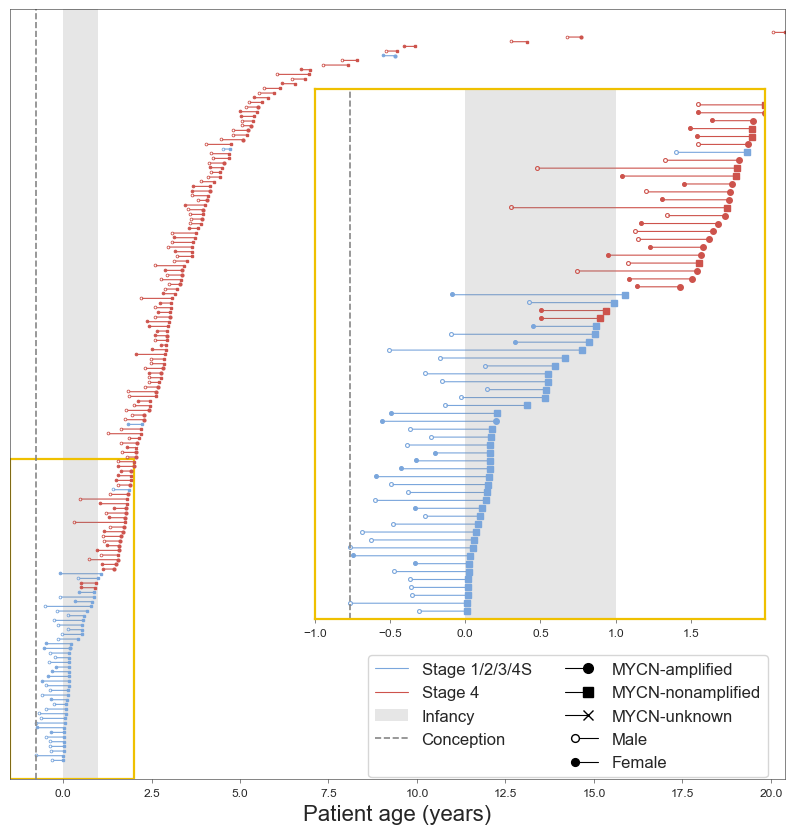

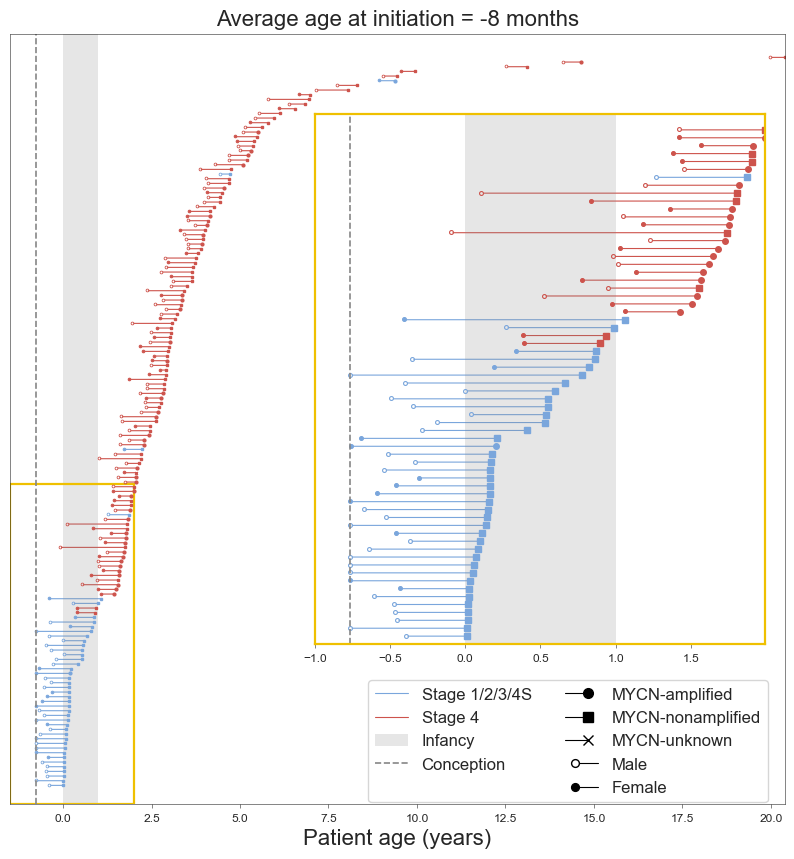

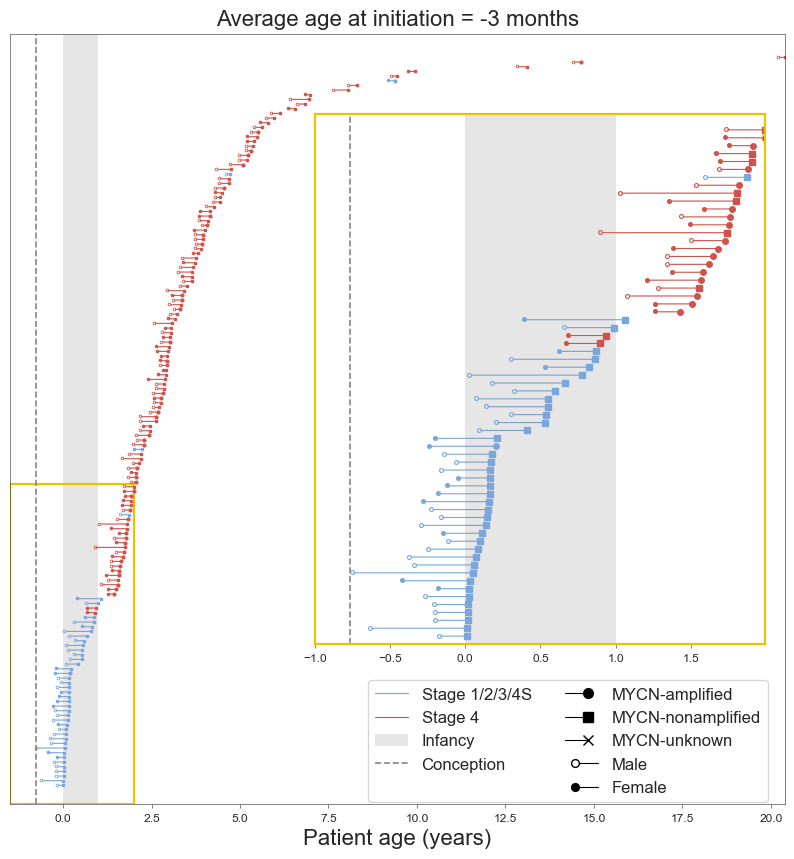

In [10]:
for calendar_age_var, title in [('calendar_age_years', ''),
                         ('calendar_age_years__8months', 'Average age at initiation = -8 months'),
                         ('calendar_age_years__3months', 'Average age at initiation = -3 months')]:

    all_patients = iad(clinical['TARGET']).index

    fig, ax = plt.subplots(figsize=np.array((25, 25)) * sf)
    xlim_left = -1.5
    y_extra = 4
    swimmersPlot(fig, ax, all_patients, xlim_left=xlim_left, y_extra=y_extra, markersize=2, calendar_age_var=calendar_age_var, line_x_offset=0.05, leftmarkersize=5, mew=1.5)

    # Overlay blown-up plot
    years_thresh = 2.0
    ax2 = fig.add_axes([0.43, 0.27, 0.45, 0.53])
    patients_younger_2_years = clinical['TARGET'].index[clinical['TARGET']['in_analysis_dataset'] & (clinical['TARGET']['Age'] <= years_thresh)]
    swimmersPlot(fig, ax2, patients_younger_2_years, legend=False, xlabel=False, xlim_left=-1, y_extra=1, markersize=4, calendar_age_var=calendar_age_var, line_x_offset=0.015, leftmarkersize=7, mew=2)
    for spine in ax2.spines.values():
        spine.set_edgecolor(nbl_consts['palette_jco'][1])
        spine.set_linewidth(4 * sf)

    ax.add_patch(
        mpatches.Rectangle((years_thresh, -y_extra), width=-years_thresh + xlim_left, height=y_extra + patients_younger_2_years.shape[0] - 0.5,
                            linewidth=4 * sf, edgecolor=nbl_consts['palette_jco'][1], facecolor='none')
    )

    ax.set_title(title, fontsize= 1.6 * nbl_consts['labelfontsize']*sf)

    # Save figure
    file_format = 'svg'
    fig.savefig(os.path.join(figure_outdir, f'swimmer_plot.meanmethod.{calendar_age_var}.{file_format}'), format=file_format, pad_inches=0.1)

# Statistics (with sensitivity analysis)

In [11]:
def pretty_print_df(df, title=None, max_rows=None, float_fmt='{:.3f}'):
    """
    Print a DataFrame in a clean, readable plain-text format.
    Good for captured stdout / HTML <pre> blocks.
    """

    import pandas as pd

    if type(df) is pd.Series:
        df = df.to_frame()

    if title is not None:
        print(title)
        print('-' * len(title))

    if max_rows is not None:
        df = df.head(max_rows)

    df_to_print = df.copy()

    # format numeric columns
    for col in df_to_print.select_dtypes(include='number').columns:
        df_to_print[col] = df_to_print[col].map(
            lambda x: float_fmt.format(x) if pd.notnull(x) else ''
        )

    print(df_to_print.to_string())
    print()

In [12]:
from IPython.display import HTML, display
from io import StringIO
from contextlib import redirect_stdout
import html

n_months_opts = [8, 6, 3]

tab_headers = []
tab_panels = []

for i, n_months in enumerate(n_months_opts, start=1):

    buffer = StringIO()

    with redirect_stdout(buffer):

        clinical['TARGET']['calendar_age'] = clinical['TARGET']['phi_div_alpha'] / get_k_mu(n_months * 30)
        clinical['TARGET']['calendar_age_years'] = clinical['TARGET']['calendar_age'] / 365

        cl = iad(clinical['TARGET'])
        cl['Initiation Age'] = cl['Age'] - cl['calendar_age_years']
        cl['Initiated after 1 year'] = cl['Initiation Age'] > 1
        # cl['Good outcome stage'] = cl['inss_stage'] != 'Stage 4'
        # cl['Good outcome stage'] = cl['Stage grouped']

        # print('Good outcome stage = Not stage 4')

        print('-' * 65)
        print('-' * 30 + ' (i) ' + '-' * 30)
        print('-' * 65)
        print()

        cl_after15 = iad(cl).loc[cl['Age'] > 1.5]
        print('Tumors detected after 1.5 years of age\n')

        print(f'Min age at tumor initiation: {cl_after15["Initiation Age"].min():.2f} yrs')
        print(f'# tumors total: {cl_after15["Initiation Age"].shape[0]}')
        print(f'# tumors initiated after 1 year of age: {cl_after15["Initiated after 1 year"].sum()}')
        print(f'Percent of tumors initiated after 1 year of age: {cl_after15["Initiated after 1 year"].mean() * 100:.1f}%')

        print()

        print('-' * 66)
        print('-' * 30 + ' (ii) ' + '-' * 30)
        print('-' * 66)
        print()

        pretty_print_df(iad(cl)['inss_stage'].value_counts(), float_fmt='{:d}')
        pretty_print_df(cl.groupby('Stage grouped')['Initiated after 1 year'].agg(['sum', 'mean']))

        print()
        print('Stage counts:')
        pretty_print_df(cl['Stage grouped'].value_counts(), float_fmt='{:d}')

        print()

        print('-' * 67)
        print('-' * 30 + ' (iii) ' + '-' * 30)
        print('-' * 67)
        print()

        print('Mean sojourn times (calendar age in days)\n')

        pretty_print_df(cl.groupby('inss_stage')['calendar_age'].agg(['mean', 'min', 'max']).map(round), float_fmt='{:d}')
        print()
        pretty_print_df(cl.groupby('Stage grouped')['calendar_age'].agg(['mean', 'min', 'max']).map(round), float_fmt='{:d}')

        ttest_res = stats.ttest_ind(
            cl.loc[cl['Stage grouped'] == 'Stage 4', 'calendar_age'],
            cl.loc[cl['Stage grouped'] == 'Stage 1/2/3/4S', 'calendar_age']
        )

        print(f'T-test, P = {ttest_res.pvalue:.0e}')

    output_html = html.escape(buffer.getvalue())

    checked = "checked" if i == 1 else ""
    label = f'{"-" if n_months > 0 else ""}{n_months} months'

    tab_headers.append(f"""
        <input type="radio" name="tabs" id="tab{i}" {checked}>
        <label for="tab{i}">{label}</label>
    """)

    tab_panels.append(f"""
        <div id="panel{i}" class="tab-panel">
            <pre>{output_html}</pre>
        </div>
    """)

panel_css = "\n".join(
    f"#tab{i}:checked ~ #panel{i} {{ display: block; }}"
    for i in range(1, len(n_months_opts) + 1)
)

html_out = f"""
<style>
.tabset > input {{
    display: none;
}}

.tabset > label {{
    display: inline-block;
    padding: 8px 14px;
    border: 1px solid #ccc;
    cursor: pointer;
    margin-right: 4px;
    background: #f7f7f7;
}}

.tabset > input:checked + label {{
    background: white;
    border-bottom: 1px solid white;
    font-weight: bold;
}}

.tabset > .tab-panel {{
    display: none;
    border: 1px solid #ccc;
    padding: 12px;
    margin-top: -1px;
}}

.tab-panel pre {{
    white-space: pre-wrap;
}}

{panel_css}

.styled-table {{
    border-collapse: collapse;
    font-size: 14px;
    min-width: 300px;
}}

.styled-table th,
.styled-table td {{
    border: 1px solid #d0d0d0;
    padding: 6px 10px;
    text-align: left;
}}

.styled-table th {{
    background-color: #f3f3f3;
    font-weight: bold;
}}

.styled-table tr:nth-child(even) {{
    background-color: #fafafa;
}}

</style>

<div class="tabset">
    {''.join(tab_headers)}
    {''.join(tab_panels)}
</div>
"""

display(HTML(html_out))